In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')


In [2]:
df_essay = pd.read_csv("../data/raw/ai_generated_essays.csv")
df_1k = pd.read_csv("../data/raw/kaggle_1k.csv")
df_500k = pd.read_csv("../data/raw/kaggle_500k.csv")

print(df_essay.shape, df_1k.shape, df_500k.shape)


(1460, 2) (1000, 6) (487235, 2)


In [3]:
# Keep only required columns and use 'generated' as the common label column
df_essay = df_essay[['text', 'generated']]
df_1k = df_1k[['text', 'label']].rename(columns={'label': 'generated'})
df_500k = df_500k[['text', 'generated']]

print("✅ Columns standardized successfully")
print("Essay:", df_essay.columns.tolist())
print("1K:", df_1k.columns.tolist())
print("500K:", df_500k.columns.tolist())


✅ Columns standardized successfully
Essay: ['text', 'generated']
1K: ['text', 'generated']
500K: ['text', 'generated']


In [4]:
# Standardize numeric labels: 0 = Human, 1 = AI
df_essay['generated'] = df_essay['generated'].astype(int)
df_500k['generated'] = df_500k['generated'].astype(int)

def map_generated(v):
    v = str(v).lower().strip()
    if v == 'human':
        return 0
    else:
        return 1

df_1k['generated'] = df_1k['generated'].apply(map_generated)


In [5]:
df = pd.concat([df_essay, df_1k, df_500k], ignore_index=True)

# Drop missing or duplicate entries
df.dropna(subset=['text', 'generated'], inplace=True)
df.drop_duplicates(subset=['text'], inplace=True)

# Convert type just to be safe
df['generated'] = df['generated'].astype(int)

print("✅ Combined dataset shape:", df.shape)
print(df['generated'].value_counts())


✅ Combined dataset shape: (488316, 2)
generated
0    305797
1    182519
Name: count, dtype: int64


In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)         # keep letters only
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.head()


,text,generated,clean_text
0,"Machine learning, a subset of artificial intel...",1,machine learning a subset of artificial intell...
1,"A decision tree, a prominent machine learning ...",1,a decision tree a prominent machine learning a...
2,"Education, a cornerstone of societal progress,...",1,education a cornerstone of societal progress e...
3,"Computers, the backbone of modern technology, ...",1,computers the backbone of modern technology ha...
4,"Chess, a timeless game of strategy and intelle...",1,chess a timeless game of strategy and intellec...


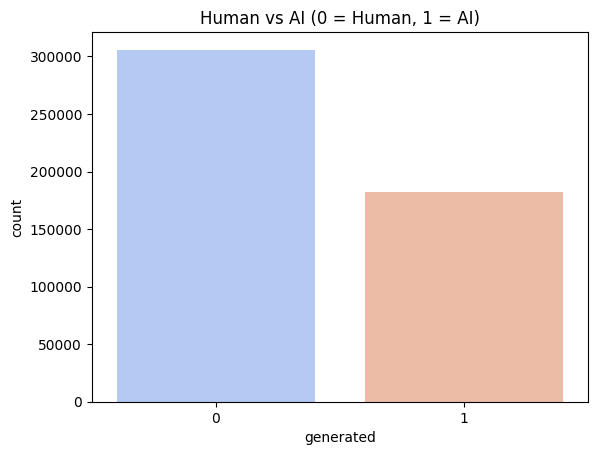

generated
0    0.626228
1    0.373772
Name: proportion, dtype: float64

In [7]:
sns.countplot(x='generated', data=df, palette='coolwarm')
plt.title('Human vs AI (0 = Human, 1 = AI)')
plt.show()

df['generated'].value_counts(normalize=True)


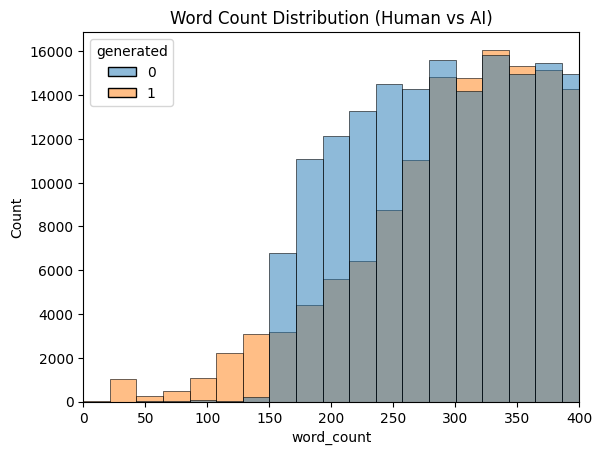

In [8]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
sns.histplot(data=df, x='word_count', hue='generated', bins=80)
plt.xlim(0, 400)
plt.title('Word Count Distribution (Human vs AI)')
plt.show()


In [9]:
print("🧠 Human samples:")
display(df[df['generated'] == 0]['clean_text'].sample(3, random_state=42))

print("\n🤖 AI samples:")
display(df[df['generated'] == 1]['clean_text'].sample(3, random_state=42))


🧠 Human samples:


262941    do curfews keep teenagers from getting into tr...
135763    in this article the challenge of exploring ven...
294011    with thp rapid growth of thp internet in recen...
Name: clean_text, dtype: object


🤖 AI samples:


46016     as a nasa scientist i understand the excitemen...
337595    the challenge of exploring venus venus is a pl...
461622    art is a form of self expression that has been...
Name: clean_text, dtype: object

In [10]:
os.makedirs("../data/processed", exist_ok=True)
df[['clean_text', 'generated']].to_csv("../data/processed/cleaned_data.csv", index=False)
print("✅ Saved cleaned dataset → ../data/processed/cleaned_data.csv")


✅ Saved cleaned dataset → ../data/processed/cleaned_data.csv
